In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Add project root to path so we can import our modules if needed
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

# Why Normalize?

In Linear Regression, we try to find the best Weight ($w$) and Bias ($b$) to minimize the error.

However, our data features often have vastly different scales:
* **Mileage (km):** Ranges from 0 to 250,000.
* **Price (€):** Ranges from 0 to 10,000.

This massive difference creates a distorted "Cost Landscape."

In [2]:
# Load the dataset
df = pd.read_csv("../../data/data.csv")
x = df["km"].to_numpy()
y = df["price"].to_numpy()

print(f"Feature (km) range:   {x.min():,.0f} to {x.max():,.0f}")
print(f"Target (price) range: {y.min():,.0f} to {y.max():,.0f}")

Feature (km) range:   22,899 to 240,000
Target (price) range: 3,650 to 8,290


### 1. The Problem: The Unscaled Cost Landscape

Let's visualize the Mean Squared Error (MSE) for various values of $w$ and $b$ using the **raw, unscaled data**.

Because `km` is huge, a tiny change in `w` (e.g., 0.001) changes the prediction by a lot ($0.001 * 200,000 = 200$).
Because `b` is just added, it needs large changes to have the same effect.

This creates an **elongated valley**.

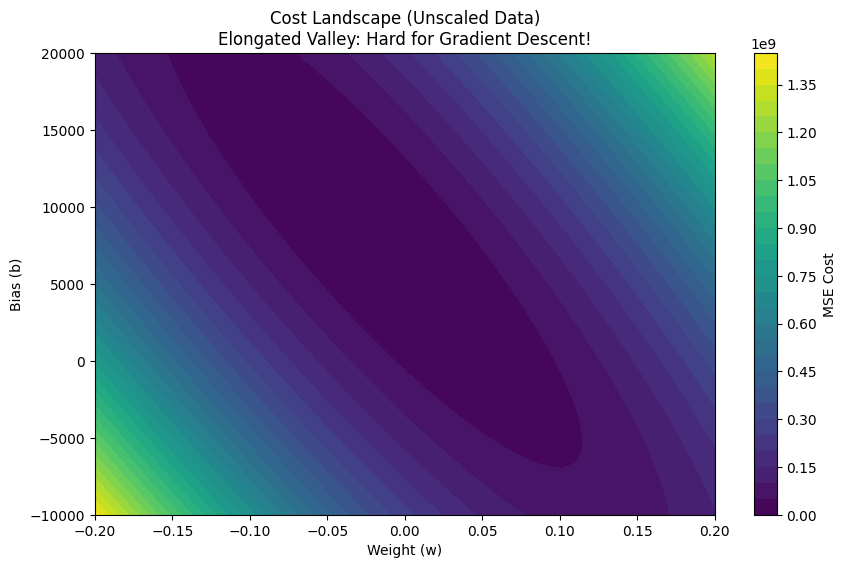

In [3]:
def compute_cost_grid(
    x_data: np.ndarray, y_data: np.ndarray, w_range: np.ndarray, b_range: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Helper to calculate MSE for a grid of w and b values"""
    w, b = np.meshgrid(w_range, b_range)
    z = np.zeros_like(w)

    for i in range(w.shape[0]):
        for j in range(w.shape[1]):
            preds = w[i, j] * x_data + b[i, j]
            z[i, j] = np.mean((preds - y_data) ** 2)

    return w, b, z


w_raw = np.linspace(-0.2, 0.2, 50)
b_raw = np.linspace(-10000, 20000, 50)

W_raw, B_raw, Z_raw = compute_cost_grid(x, y, w_raw, b_raw)

plt.figure(figsize=(10, 6))
plt.contourf(W_raw, B_raw, Z_raw, levels=30, cmap="viridis")
plt.colorbar(label="MSE Cost")
plt.title(
    "Cost Landscape (Unscaled Data)\nElongated Valley: Hard for Gradient Descent!"
)
plt.xlabel("Weight (w)")
plt.ylabel("Bias (b)")
plt.show()

### 2. Min-Max Normalization

Scales data to a fixed range, usually $[0, 1]$.

$$
x' = \frac{x - \min(x)}{\max(x) - \min(x)}
$$

**Pros:** Preserves the exact distribution shape.
<br>**Cons:** Sensitive to outliers (one huge value squashes everything else).

### 3. Z-Score Normalization (Standardization)

Centers the data around 0 with a standard deviation of 1.

$$
x' = \frac{x - \mu}{\sigma}
$$

**Pros:** Handles outliers better; centers the "bowl" at (0,0).
<br>**Cons:** Doesn't produce a fixed range (e.g. could be -3 to +3).

mean : 3.700743415417188e-17
std : 1.0


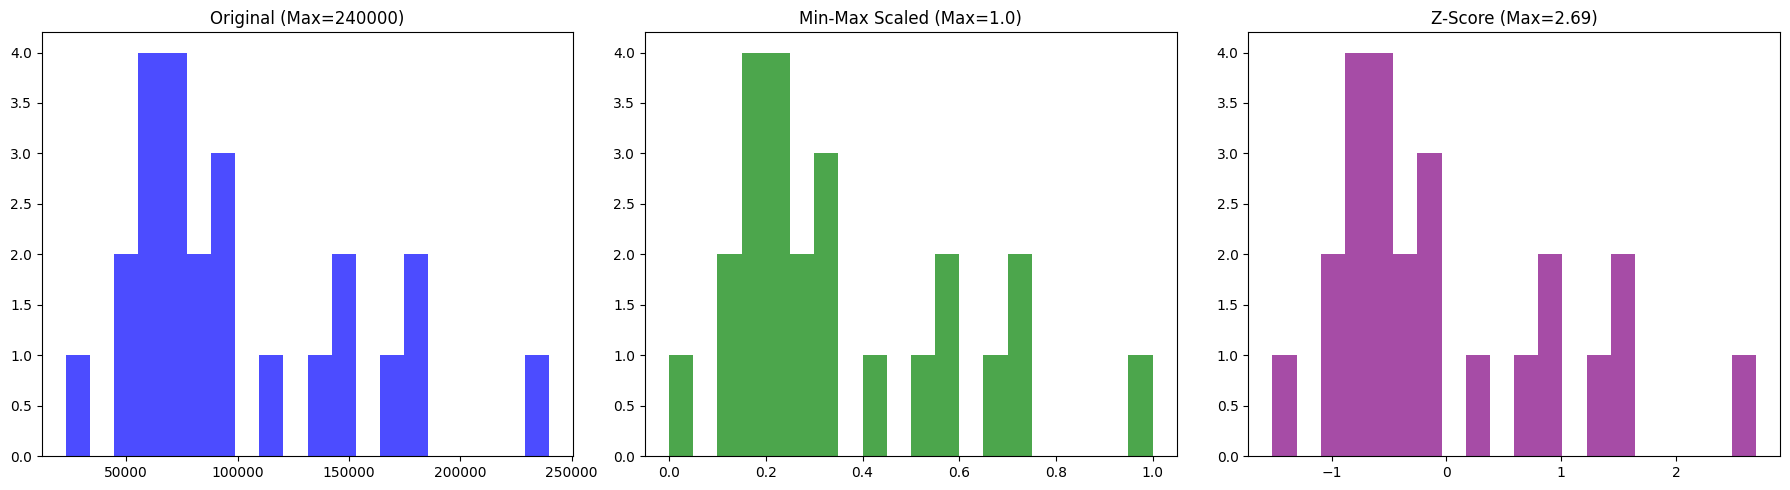

In [4]:
def min_max(values: np.ndarray) -> np.ndarray:
    return (values - values.min()) / (values.max() - values.min())


def z_score(values: np.ndarray) -> np.ndarray:
    return (values - values.mean()) / values.std()


x_minmax = min_max(x)
y_minmax = min_max(y)

x_z_score = z_score(x)
y_z_score = z_score(y)

print("mean :", x_z_score.mean())
print("std :", x_z_score.std())

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.hist(x, bins=20, color="blue", alpha=0.7)
plt.title(f"Original (Max={x.max()})")

plt.subplot(1, 3, 2)
plt.hist(x_minmax, bins=20, color="green", alpha=0.7)
plt.title(f"Min-Max Scaled (Max={x_minmax.max()})")

plt.subplot(1, 3, 3)
plt.hist(x_z_score, bins=20, color="purple", alpha=0.7)
plt.title(f"Z-Score (Max={x_z_score.max():.2f})")

plt.tight_layout()
plt.show()

### 4. The Solution: The Scaled Cost Landscape

Now let's look at the MSE landscape using the **scaled data**.

Since both $x$ and $y$ are roughly in the range $[-2, 2]$, the optimal $w$ and $b$ will also be in a small, symmetric range.

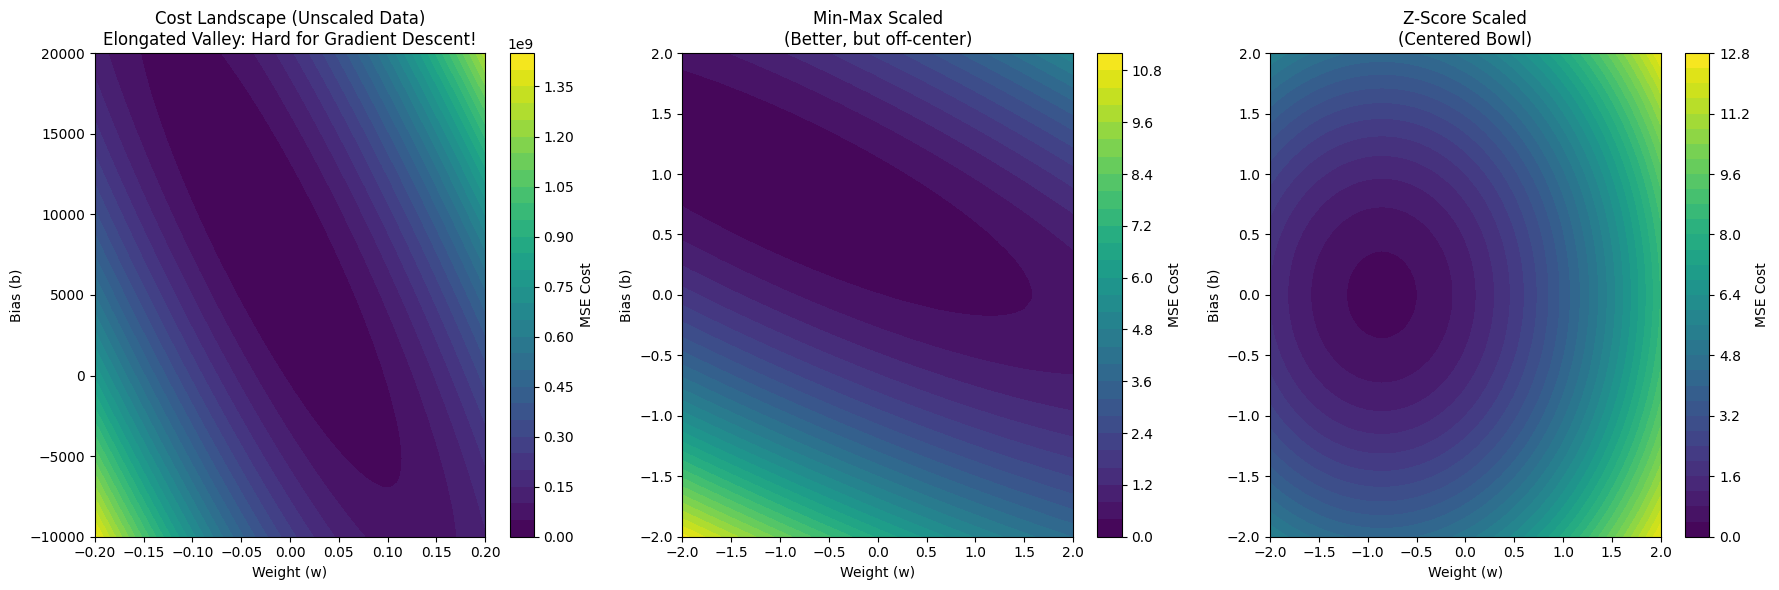

In [5]:
w_range_sc = np.linspace(-2, 2, 50)
b_range_sc = np.linspace(-2, 2, 50)

w_minmax_sc, b_minmax_sc, z_minmax_sc = compute_cost_grid(
    x_minmax, y_minmax, w_range_sc, b_range_sc
)
w_z_sc, b_z_sc, z_z_sc = compute_cost_grid(x_z_score, y_z_score, w_range_sc, b_range_sc)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.contourf(W_raw, B_raw, Z_raw, levels=30, cmap="viridis")
plt.colorbar(label="MSE Cost")
plt.title(
    "Cost Landscape (Unscaled Data)\nElongated Valley: Hard for Gradient Descent!"
)
plt.xlabel("Weight (w)")
plt.ylabel("Bias (b)")


plt.subplot(1, 3, 2)
plt.contourf(w_minmax_sc, b_minmax_sc, z_minmax_sc, levels=30, cmap="viridis")
plt.colorbar(label="MSE Cost")
plt.title("Min-Max Scaled\n(Better, but off-center)")
plt.xlabel("Weight (w)")
plt.ylabel("Bias (b)")

plt.subplot(1, 3, 3)
plt.contourf(w_z_sc, b_z_sc, z_z_sc, levels=30, cmap="viridis")
plt.colorbar(label="MSE Cost")
plt.title("Z-Score Scaled\n(Centered Bowl)")
plt.xlabel("Weight (w)")
plt.ylabel("Bias (b)")

plt.tight_layout()
plt.show()

### 5. The reverse

We will now be using the scaled data to work on the data.

To reverse the normalisation

#### Min-max

$$
x' = \frac{x - \min(x)}{\max(x) - \min(x)}
$$

Denormalize

$$
x = x' * (\max(x) - \min(x)) + \min(x)
$$

#### z-score

$$
x' = \frac{x - \mu}{\sigma}
$$

Denormalize 

$$
x = x' * \sigma + \mu
$$

### Summary

1.  **Unscaled:** The gradients for $w$ are huge, and for $b$ are small. You have to use a tiny Learning Rate to avoid exploding, but that makes $b$ update painfully slowly.
2.  **Scaled:** The gradients are balanced. You can use a larger Learning Rate (e.g., 0.1) and converge quickly in all directions.